# PyTorch Primer

We'll use Python and [PyTorch](https://pytorch.org/) for the labs in this course. This lab is to help you get up to speed. It will introduce:
- **Tensors**: PyTorch's equivalent of NumPy arrays, but with more bells and whistles for running on GPUs and supporting automatic differentiation.
- **Broadcasting and Fancy Indexing**: If you're coming from Matlab or NumPy, you probably know that you can avoid costly for-loops by broadcasting computation over dimensions of an array (here, tensor) and using fancy indexing tricks. 
- **Distributions**: PyTorch has an excellent library of distributions for sampling, evaluating log probabilities, and much more. 

We'll introduce these concepts in the context of the Poisson mixture model from class (c.f. [Probabilistic Modeling](../lectures/02_probabilistic_modeling.ipynb)).

In [1]:
import torch
import torch.distributions as dist
import matplotlib.pyplot as plt

## 1. Constructing Tensors

Tensors are PyTorch's equivalent of NumPy arrays. The PyTorch documentation already has a [great tutorial](https://pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html) on tensors. Rather than recreate the wheel, please start by reading that.

Once you've read through that, try using torch functions like `arange`, `reshape`, etc. to construct the following tensors.

### Problem 1.1

Construct the following tensor:

```
tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])
```

_Note: For this problems and the ones below, don't literally construct the tensor from the specified list. Use torch functions._

---

In [2]:
# YOUR CODE HERE
a = torch.arange(9).reshape(3,3)
a

tensor([[0, 1, 2],
        [3, 4, 5],
        [6, 7, 8]])

### Problem 1.2

Construct the following tensor:

```
tensor([[0, 3, 6],
        [1, 4, 7],
        [2, 5, 8]])
```

---

In [3]:
# YOUR CODE HERE
b = a.T
b

tensor([[0, 3, 6],
        [1, 4, 7],
        [2, 5, 8]])

### Problem 1.3

Construct the following tensor:

```
tensor([0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4])
```

_Note: Here the sequence is repeated 3 times. Does your code support arbitrary numbers of repeats?_

---

In [4]:
# YOUR CODE HERE
c = torch.arange(5).repeat(3,)
c

tensor([0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4])

### Problem 1.4

Construct the following tensor:

```
tensor([[0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4]])
```

---

In [5]:
# YOUR CODE HERE
d = torch.arange(5).repeat(3,1)
d

tensor([[0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4],
        [0, 1, 2, 3, 4]])

### Problem 1.5

Construct the following tensor:

```
tensor([[ 1., -2.,  0.,  0.],
        [-2.,  1., -2.,  0.],
        [ 0., -2.,  1., -2.],
        [ 0.,  0., -2.,  1.]])
```

---

In [6]:
# YOUR CODE HERE
e = torch.tensor([[1.,-2.,0.,0.],[-2.,1.,-2.,0.],[0.,-2.,1.,-2.],[0.,0.,-2.,1.]],dtype=torch.float32)
e

tensor([[ 1., -2.,  0.,  0.],
        [-2.,  1., -2.,  0.],
        [ 0., -2.,  1., -2.],
        [ 0.,  0., -2.,  1.]])

### Problem 1.6

Construct the following tensor:

```
tensor([[[[0, 1, 2]]]])
```

---

In [7]:
# YOUR CODE HERE
f = torch.arange(3).reshape(1,1,1,3)
f

tensor([[[[0, 1, 2]]]])

$$
A=\begin{pmatrix}
-1 & 4 & -3 & 1\\
-8 & 23 & -21 & 7\\
-26 & 74 & -70 & 23\\
-61 & 174 & -166 & 54\\
\end{pmatrix}
$$
求一个非异矩阵 X 使 $A=XTX^{-1}$，其中 $T$ 为上三角阵的矩阵  

事实上，可以算出当：  
$$
T=\begin{pmatrix}
1 & -1 & 1 & 1 \\
0 & 1 & -6 & -6 \\
0 & 0 & 2+i & 0 \\
0 & 0 & 0 & 2-i\\
\end{pmatrix},
X=\begin{pmatrix}
1 & 0 & 0 & 0\\
1 & -1 & 0 & 0\\
1 & -2 & 3-i & 3+i\\
1 & -3 & 10-3i & 10+3i\\
\end{pmatrix}
时，成立。
$$


In [8]:
import numpy as np
import torch

# --------------------  NumPy 验证 --------------------
print("="*50)
print("NumPy 验证")
print("="*50)

# 定义矩阵 A (整数，自动转为复数)
A_np = np.array([
    [-1,  4,  -3,  1],
    [-8, 23, -21, 7],
    [-26, 74, -70, 23],
    [-61,174,-166,54]
], dtype=np.complex128)

# 定义矩阵 T (上三角，复数)
T_np = np.array([
    [1, -1, 1, 1],
    [0, 1, -6, -6],
    [0, 0, 2+1j, 0],
    [0, 0, 0, 2-1j]
], dtype=np.complex128)

# 定义矩阵 X (下三角形式，复数)
X_np = np.array([
    [1, 0, 0, 0],
    [1, -1, 0, 0],
    [1, -2, 3-1j, 3+1j],
    [1, -3, 10-3j, 10+3j]
], dtype=np.complex128)

# 计算 X 的逆
X_inv_np = np.linalg.inv(X_np)

# 计算 X * T * X^{-1}
reconstructed_np = X_np @ T_np @ X_inv_np

# 验证是否与 A 相等（考虑浮点误差）
if np.allclose(reconstructed_np, A_np):
    print("NumPy 验证通过：A = X T X^{-1} 成立。")
else:
    print("NumPy 验证失败：结果与 A 不一致。")
    # 打印最大差异
    diff = np.abs(reconstructed_np - A_np).max()
    print(f"最大绝对误差 = {diff}")

# --------------------  PyTorch 验证 --------------------
print("\n" + "="*50)
print("PyTorch 验证")
print("="*50)

# 将数据转为 PyTorch 复数张量（需要 torch.complex128）
A_pt = torch.tensor(A_np, dtype=torch.complex128)      # 从 NumPy 转换
T_pt = torch.tensor(T_np, dtype=torch.complex128)
X_pt = torch.tensor(X_np, dtype=torch.complex128)

# 计算 X 的逆（PyTorch 使用 torch.linalg.inv）
X_inv_pt = torch.linalg.inv(X_pt)

# 计算 X * T * X^{-1}
reconstructed_pt = X_pt @ T_pt @ X_inv_pt

# 验证
if torch.allclose(reconstructed_pt, A_pt):
    print("PyTorch 验证通过：A = X T X^{-1} 成立。")
else:
    print("PyTorch 验证失败：结果与 A 不一致。")
    diff = torch.max(torch.abs(reconstructed_pt - A_pt)).item()
    print(f"最大绝对误差 = {diff}")

NumPy 验证
NumPy 验证通过：A = X T X^{-1} 成立。

PyTorch 验证
PyTorch 验证通过：A = X T X^{-1} 成立。


In [9]:
X3=np.array([[3-1j,3+1j],[1,1]],dtype=np.complex128)
X3_inv=np.linalg.inv(X3)
R3=np.array([[1,0,-6],[0,-1,10],[0,-1,5]],dtype=np.complex128)
X3_l=np.array([[1,0,0],[0,3-1j,3+1j],[0,1,1]],dtype=np.complex128)
X3_l @ R3 @ np.linalg.inv(X3_l)

array([[ 1.00000000e+00 +0.j ,  3.33066907e-16 +3.j ,
        -3.00000000e+00 -9.j ],
       [ 0.00000000e+00 +0.j , -2.50000000e+00-25.5j,
         2.70000000e+01+74.j ],
       [ 0.00000000e+00 +0.j , -9.43689571e-16 -8.5j,
         6.50000000e+00+25.5j]])

## 2. Broadcasting and Fancy Indexing

Your life will be much easier and your code will be much faster once you get the hang of broadcasting and indexing. Start by reading the  [PyTorch documentation](https://pytorch.org/docs/stable/notes/broadcasting.html).

### Problem 2.1

Construct a tensor `X` where `X[i,j] = i + j` by broadcasting a sum of two 1-dimensional tensors.

For example, broadcast a sum to construct the following tensor, 

```
tensor([[0, 1, 2],
        [1, 2, 3],
        [2, 3, 4],
        [3, 4, 5]])
```        

---

In [10]:
# YOUR CODE HERE
g = torch.arange(3).reshape(1,3) + torch.arange(4).reshape(4,1)
# either has size 1 or equal size
g

tensor([[0, 1, 2],
        [1, 2, 3],
        [2, 3, 4],
        [3, 4, 5]])

### Problem 2.2

Compute a distance matrix `D` where `D[i,j]` is the Euclidean distance between `X[i]` and `X[j]`, with

```
X = torch.arange(10, dtype=float).reshape(5, 2)
```

Your answer should be,

```
tensor([[ 0.0000,  2.8284,  5.6569,  8.4853, 11.3137],
        [ 2.8284,  0.0000,  2.8284,  5.6569,  8.4853],
        [ 5.6569,  2.8284,  0.0000,  2.8284,  5.6569],
        [ 8.4853,  5.6569,  2.8284,  0.0000,  2.8284],
        [11.3137,  8.4853,  5.6569,  2.8284,  0.0000]])
```        

---

In [11]:
X = torch.arange(10, dtype=float).reshape(5, 2)
# YOUR CODE HERE
D = torch.sqrt(torch.sum((X.unsqueeze(1) - X)**2, dim=-1))
D


tensor([[ 0.0000,  2.8284,  5.6569,  8.4853, 11.3137],
        [ 2.8284,  0.0000,  2.8284,  5.6569,  8.4853],
        [ 5.6569,  2.8284,  0.0000,  2.8284,  5.6569],
        [ 8.4853,  5.6569,  2.8284,  0.0000,  2.8284],
        [11.3137,  8.4853,  5.6569,  2.8284,  0.0000]], dtype=torch.float64)

### Problem 2.3 

Extract the submatrix of rows `[2,3]` and columns `[0,1,4]` of the tensor,
```
A = torch.arange(25).reshape(5, 5)
```

Your answer should be,
```
tensor([[10, 11, 14],
        [15, 16, 19]])
```

---

In [12]:
A = torch.arange(25).reshape(5, 5)
# YOUR CODE HERE
A[2:4,[0,1,4]]

tensor([[10, 11, 14],
        [15, 16, 19]])

### Problem 2.4

Create a binary mask matrix `M` of the same shape as `A` where `M[i,j]` is True if and only if `A[i,j]` is divisible by 7. Let

```
A = torch.arange(25).reshape(5, 5)
```

Your answer should be 

```
tensor([[ True, False, False, False, False],
        [False, False,  True, False, False],
        [False, False, False, False,  True],
        [False, False, False, False, False],
        [False,  True, False, False, False]])
```

---

In [13]:
A = torch.arange(25).reshape(5, 5)
# YOUR CODE HERE
(A%7).to(torch.bool)==False

tensor([[ True, False, False, False, False],
        [False, False,  True, False, False],
        [False, False, False, False,  True],
        [False, False, False, False, False],
        [False,  True, False, False, False]])

### Problem 2.5

Add one to the entries in `A` that are divisible by 7. After updating in place, `A` should be,

```
tensor([[ 1,  1,  2,  3,  4],
        [ 5,  6,  8,  8,  9],
        [10, 11, 12, 13, 15],
        [15, 16, 17, 18, 19],
        [20, 22, 22, 23, 24]])
```

---

In [14]:
# YOUR CODE HERE
B = (A%7).to(torch.bool)==False
B.to(torch.int32) + A

tensor([[ 1,  1,  2,  3,  4],
        [ 5,  6,  8,  8,  9],
        [10, 11, 12, 13, 15],
        [15, 16, 17, 18, 19],
        [20, 22, 22, 23, 24]])

## 3. Distributions

PyTorch has an excellent library of distributions in `torch.distributions`. Read the docs [here](https://pytorch.org/docs/stable/distributions.html).

We will use these distribution objects to construct and fit a Poisson mixture model.

### Problem 3.1

Draw 50 samples from a Poisson distribution with rate 10.

---

[(0.0, 50.0),

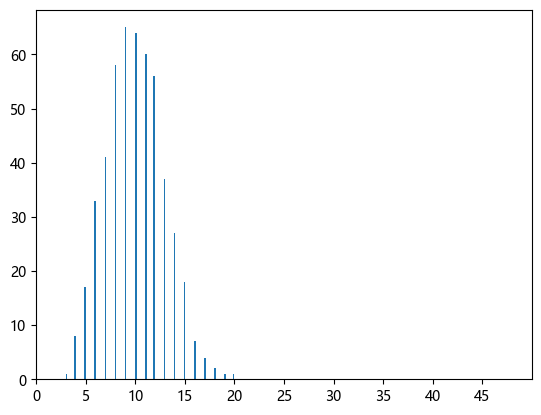

In [15]:
# YOUR CODE HERE
import torch.distributions
import numpy as np
import matplotlib.pyplot as plt

rate = 10
sample_num = 500
dist = torch.distributions.Poisson(torch.tensor([rate],dtype=torch.float32))
x = dist.sample(sample_shape=(sample_num,))
fig, ax = plt.subplots()
ax.hist(x,bins=100)

ax.set(xlim=(0, 50), xticks=np.arange(0,50,5))

### Problem 3.2

One of the awesome thing about PyTorch distributions is that they support broadcasting too. 

Construct a matrix `P` where `P[i,j]` equals $\mathrm{Pois}(x=j; \lambda=i)$ for $i=0,\ldots,4$ and $j=0,\ldots,4$.

Your answer should be,
```
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3679, 0.3679, 0.1839, 0.0613, 0.0153],
        [0.1353, 0.2707, 0.2707, 0.1804, 0.0902],
        [0.0498, 0.1494, 0.2240, 0.2240, 0.1680],
        [0.0183, 0.0733, 0.1465, 0.1954, 0.1954]])
```

---

In [16]:
# YOUR CODE HERE
l = torch.arange(5, dtype=torch.float32).reshape(5,1)
pois = torch.distributions.Poisson(l)
x = torch.arange(5, dtype=torch.float32)
torch.exp(pois.log_prob(x))

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3679, 0.3679, 0.1839, 0.0613, 0.0153],
        [0.1353, 0.2707, 0.2707, 0.1804, 0.0902],
        [0.0498, 0.1494, 0.2240, 0.2240, 0.1680],
        [0.0183, 0.0733, 0.1465, 0.1954, 0.1954]])

### Problem 3.3

Evaluate the log probability of the points `[1.5, 3., 4.2]` under a gamma distribution with shape (aka concentration) 2.0 and inverse scale (aka rate) 1.5.

Your answer should be,

```
tensor([-1.0336, -2.5905, -4.0540])
```

---

In [17]:
# YOUR CODE HERE
concentration = torch.tensor([2.0], dtype=torch.float32)
rate = torch.tensor([1.5], dtype=torch.float32)
x = torch.tensor([1.5,3.,4.2], dtype=torch.float32)
g = torch.distributions.Gamma(concentration,rate)
g.log_prob(x)

tensor([-1.0336, -2.5905, -4.0540])

### Problem 3.4

Draw 1000 samples from a Poisson mixture model,

$$
\begin{align*}
p(x) &= \frac{1}{2} \mathrm{Pois}(10.0) + \frac{1}{2} \mathrm{Pois}(2.0)
\end{align*}
$$

Use `matplotlib.pyplot.hist` to plot a normalized histogram of the samples.

---

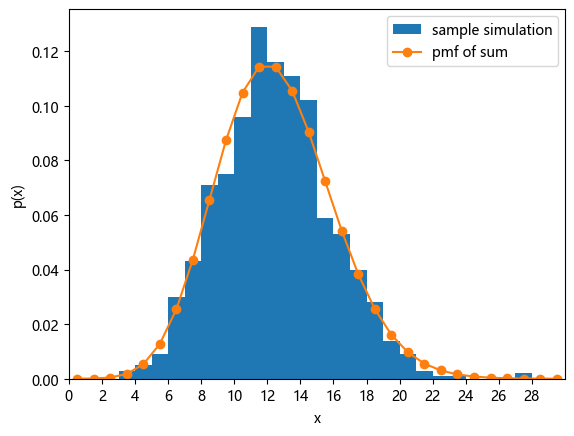

In [18]:
# YOUR CODE HERE
import torch.distributions
import matplotlib.pyplot as plt
a = torch.distributions.Poisson(torch.tensor([10.0],dtype=torch.float32))
b = torch.distributions.Poisson(torch.tensor([2.0],dtype=torch.float32))
c = torch.distributions.Poisson(torch.tensor([12.0],dtype=torch.float32))
x = a.sample((1000,)) + b.sample((1000,))
# Verify the Additivity of Poisson Distribution
fig,ax = plt.subplots()
bins = torch.arange(30)
ax.hist(x, bins, density=True, label='sample simulation')
ax.plot(bins +.5, torch.exp(c.log_prob(bins)),'-o', label='pmf of sum')
ax.set(xlim=[0,30], xticks=np.arange(0,30,2))
ax.set_xlabel("x")
ax.set_ylabel("p(x)")
ax.legend()
plt.show()
data = 1/2 * x
data = data.flatten()

## 4. MAP estimation

### Problem 4.1

Let `data` be the samples from above. Assume there are $K = 2$ clusters and the prior cluster probabilities $[\tfrac{1}{2}, \tfrac{1}{2}]$ are known. Complete the code below to perform MAP estimation.

---


estimated rates: tensor([7.2111, 4.5206])
assignments shape torch.Size([1000])
assignment 1 frequency tensor(0.4610)


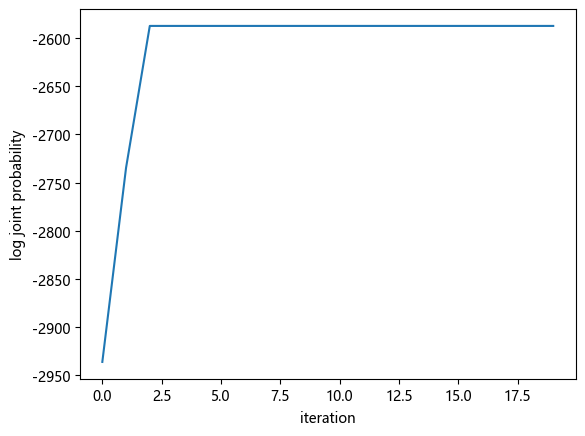

In [19]:
def update_assignments(data, rates, probs):
    """Update the cluster assignments ($z$) given the data, rates, 
    and cluster probabilities.

    Args:
        data: shape `(N,)` tensor of counts
        rates: shape `(K,)` tensor of nonnegative rates for each cluster.
        probs: shape `(K,)` tensor of cluster probabilities
        
    Returns:
        assignments: shape `(N,)` tensor of integer cluster assignments
    """
    ##
    # YOUR CODE HERE
    data = data.flatten().to(torch.int64).to(torch.float32)
    rates = rates.to(torch.float32)
    probs = probs.to(torch.float32)
    
    poisson_dist = torch.distributions.Poisson(rates.unsqueeze(-1))
    log_likelihood = poisson_dist.log_prob(data.unsqueeze(0)) # shape=(K,N)
    
    log_priors = torch.log(probs).reshape(-1,1)
    log_posterior = log_likelihood + log_priors
    
    assignments = torch.argmax(log_posterior, dim=0)
    ##
    return assignments

def update_rates(data, assignments, shape=1.0, inv_scale=1.0):
    """Update the rates for each cluster under a gamma prior.

    Args:
        data: shape `(N,)` tensor of counts
        assignments: shape `(N,)` tensor of integer cluster assignments
        shape: shape (aka concentration) of gamma prior. Defaults to 1.0.
        inv_scale: inverse scale (aka rate) of gamma prior. Defaults to 1.0.
        
    Returns:
        rates: shape `(K,)` tensor of updated rates for each cluster
    """
    ##
    # YOUR CODE HERE
    data = data.flatten().to(torch.float32)
    assignments = assignments.to(torch.int64)
    
    K = assignments.max().item() + 1
    N = assignments.numel()
    
    if(N != data.numel()):
        print("assignments do not match with data")
        print(data.numel())
        
    # 若输入是标量，转为(K,)的张量；若已是(K,)，直接使用
    shape_prior = torch.as_tensor(shape, dtype=torch.float32)
    shape_prior = shape_prior.expand(K)  # 形状(K,)
    inv_scale_prior = torch.as_tensor(inv_scale, dtype=torch.float32)
    inv_scale_prior = inv_scale_prior.expand(K)    # 形状(K,)
    
    coef = torch.arange(K,dtype=torch.int64).unsqueeze(-1) == assignments.unsqueeze(0) # shape=(K,N)
    coef = coef.to(torch.float32)
    shape_add = torch.sum(coef * data, dim=1)  # 沿N维度求和 → (K,)
    inv_scale_add = torch.sum(coef, dim=1)         # 沿N维度求和 → (K,)
    
    shape_posterior = shape_prior + shape_add
    inv_scale_posterior = inv_scale_prior + inv_scale_add
    
    rates = (shape_posterior - 1)/(inv_scale_posterior + 1e-8)
    ##
    return rates
    

def log_joint(data, assignments, rates, probs, shape=1.0, inv_scale=1.0):
    """_summary_

    Args:
        data: shape `(N,)` tensor of counts
        assignments: shape `(N,)` tensor of integer cluster assignments
        rates: shape `(K,)` tensor of updated rates for each cluster
        probs: shape `(K,)` tensor of cluster probabilities
        shape: shape (aka concentration) of gamma prior. Defaults to 1.0.
        inv_scale: inverse scale (aka rate) of gamma prior. Defaults to 1.0.
        
    Returns:
        lp: scalar log joint probability under the mixture model
    """
    ###
    # YOUR CODE HERE
    # 先处理 data 要求不为小数，但可以是 float 型整数
    data = data.flatten() 
    data = data.to(torch.int64)
    data = data.to(torch.float32)
    
    rates = rates.to(torch.float32)
    probs = probs.to(torch.float32)
    assignments = assignments.to(torch.int64)
    
    # 步骤2：推导K和N（避免硬编码）
    K = rates.size(0)  
    N = data.numel()   
    
    # 若输入是标量，转为(K,)的张量；若已是(K,)，直接使用
    shape_prior = torch.as_tensor(shape, dtype=torch.float32)
    shape_prior = shape_prior.expand(K)
    inv_scale_prior = torch.as_tensor(inv_scale, dtype=torch.float32)
    inv_scale_prior = inv_scale_prior.expand(K)
    
    gamma_dist = torch.distributions.Gamma(shape_prior, inv_scale_prior)
    gamma_log_prob = gamma_dist.log_prob(rates).sum()  # 所有簇的Gamma先验对数和
    
    cluster_prior_log_prob = torch.log(probs[assignments]).sum()  # 所有数据点的簇先验对数和
    
    # 直接索引rates，得到每个数据点对应的λ（形状(N,)）
    lambda_n = rates[assignments]  # 无需转numpy，直接张量索引
    poisson_dist = torch.distributions.Poisson(lambda_n)
    poisson_log_prob = poisson_dist.log_prob(data).sum()  # 所有数据点的Poisson似然对数和
    
    ## log joint 直接相加
    lp = gamma_log_prob + cluster_prior_log_prob + poisson_log_prob
    
    return lp
    
# Run coordinate ascent for some number of iterations, starting
# with random cluster assignments
probs = torch.ones(2) / 2.0
assignments = torch.randint(0, 2, data.shape)
rates = 10 * torch.rand(2)

lps = []
for i in range(20):
    lps.append(log_joint(data, assignments, rates, probs))
    rates = update_rates(data, assignments)
    assignments = update_assignments(data, rates, probs)
    
fig,ax = plt.subplots()   
ax.plot(lps)
ax.set_xlabel("iteration")
ax.set_ylabel("log joint probability")

print("estimated rates:", rates)
print("assignments shape",assignments.shape)
print("assignment 1 frequency", assignments.sum()/assignments.numel())


### Problem 4.2 (Bonus)

Now consider a more general model in which 

$$
z_n \sim \mathrm{Cat}(\boldsymbol{\pi})
$$

where the prior cluster probabilities $\boldsymbol{\pi}$ are unknown. (Above, we assumed they were known to be $\boldsymbol{\pi} = [\tfrac{1}{2}, \tfrac{1}{2}]$.) Derive and implement a coordinate ascent algorithm for MAP estimation of $\mathbf{z}_{\mathsf{MAP}}$, $\boldsymbol{\lambda}_{\mathsf{MAP}}$, and $\boldsymbol{\pi}_{\mathsf{MAP}}$.


estimated rates: tensor([4.5206, 7.2111])
estimated \pi:


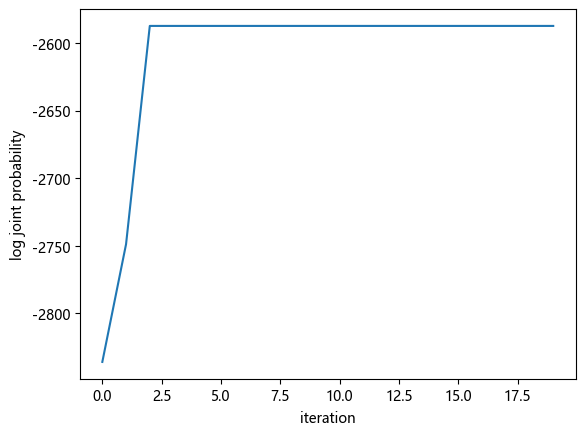

In [20]:
# Run coordinate ascent for some number of iterations, starting
# with random cluster assignments
probs = torch.ones(2) / 2.0
assignments = torch.randint(0, 2, data.shape)
rates = 10 * torch.rand(2)

lps = []
for i in range(20):
    lps.append(log_joint(data, assignments, rates, probs))
    rates = update_rates(data, assignments)
    assignments = update_assignments(data, rates, probs)
    
plt.plot(lps)
plt.xlabel("iteration")
plt.ylabel("log joint probability")

print("estimated rates:", rates)
print("estimated \pi:", )